# Quantity Analysis - Time Series

## Objective
Analyze and forecast **quantity trends** over time using time series analysis techniques.

## Dataset Overview
The dataset contains timestamped records of quantities sold or produced.

## Workflow
1. Load the data
2. Explore time-based patterns
3. Resample and smooth
4. Train a forecasting model
5. Visualize predictions

In [16]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")


In [17]:
df = pd.read_excel("Raw Data_Predictive Analysis.xlsx")

print(df.head())

   OrderDate  ParentProductIdNew ParentProductNew ProductCategoryNew  \
0 2019-01-01                  11       Product 11         Category 1   
1 2019-01-01                 114      Product 114         Category 8   
2 2019-01-01                  98       Product 98         Category 8   
3 2019-01-01                  97       Product 97         Category 8   
4 2019-01-01                   8        Product 8         Category 1   

  ArtistNameNew  total_qty_sales  Selling Price  productListViews  \
0         TSSOS                3          399.0               NaN   
1          TSSA               10          549.0               NaN   
2         TSSHT                8          499.0               NaN   
3          TSSF                6          549.0               NaN   
4         TSSML                6          399.0               NaN   

   productListClicks  
0                NaN  
1                NaN  
2                NaN  
3                NaN  
4                NaN  


## Exploratory Data Analysis

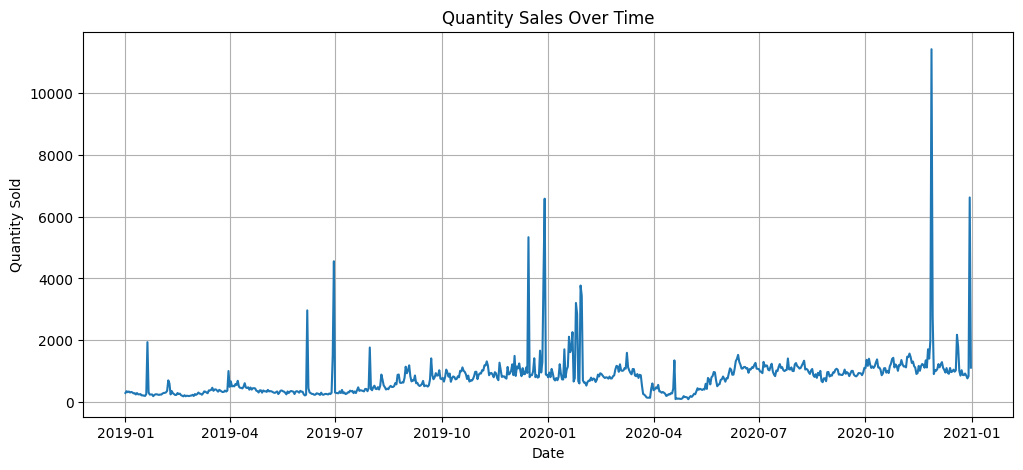

In [18]:
import matplotlib.pyplot as plt

# Convert to datetime if necessary
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Plot raw time series
daily_qty = df.groupby('OrderDate')['total_qty_sales'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_qty)
plt.title('Quantity Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')
plt.grid(True)
plt.show()

## Decomposition

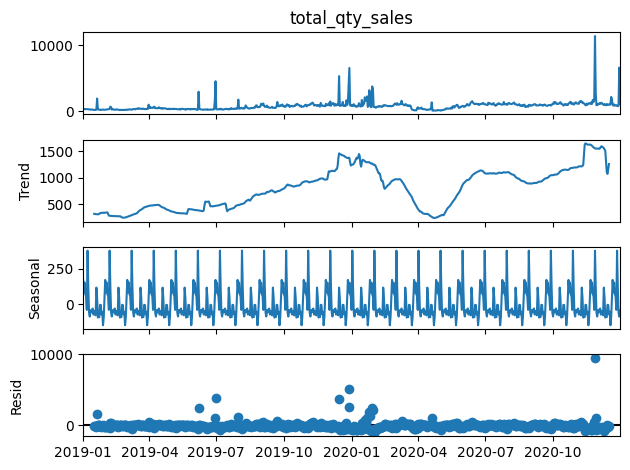

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set date as index
daily_qty = daily_qty.asfreq('D').fillna(0)

# Decompose
result = seasonal_decompose(
    daily_qty,
    model='additive',
    period=30
)

result.plot()
plt.show()

## Modeling with ARIMA

In [20]:
from statsmodels.tsa.arima.model import ARIMA

# Train-test split
train_size = int(len(daily_qty) * 0.8)

train = daily_qty[:train_size]
test = daily_qty[train_size:]


# Fit ARIMA model
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

# Forecast
predictions = model_fit.forecast(steps=len(test))

                               SARIMAX Results                                
Dep. Variable:        total_qty_sales   No. Observations:                  584
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -4424.823
Date:                Sat, 20 Jun 2026   AIC                           8861.647
Time:                        02:06:35   BIC                           8887.856
Sample:                    01-01-2019   HQIC                          8871.862
                         - 08-06-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5412      0.014    -40.058      0.000      -0.568      -0.515
ar.L2         -0.5612      0.023    -24.278      0.000      -0.607      -0.516
ar.L3         -0.3881      0.026    -15.011      0.0

## Evaluation and Visualization

Mean Squared Error: 998799.838854986


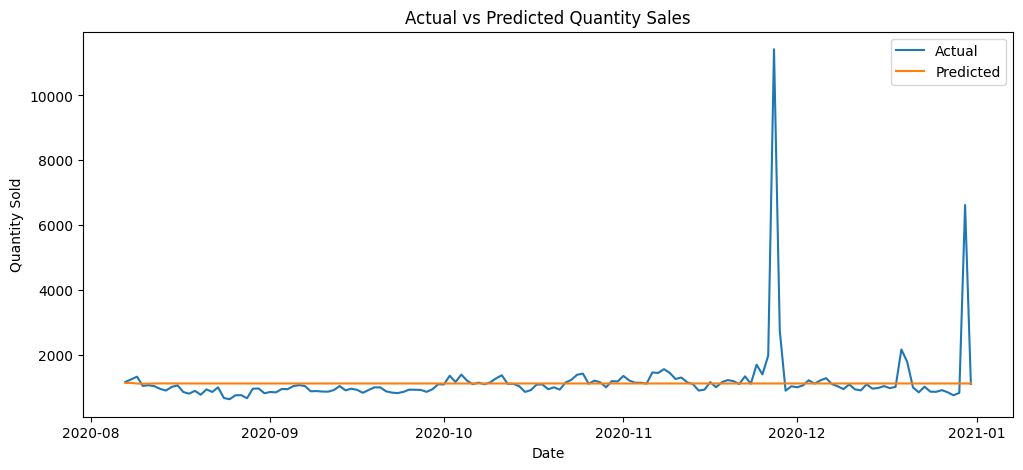

In [21]:
from sklearn.metrics import mean_squared_error

# Evaluation
mse = mean_squared_error(test, predictions)

print("Mean Squared Error:", mse)


# Plot forecast vs actual
plt.figure(figsize=(12,5))

plt.plot(test.index, test,
         label='Actual')

plt.plot(test.index, predictions,
         label='Predicted')

plt.title('Actual vs Predicted Quantity Sales')

plt.xlabel('Date')
plt.ylabel('Quantity Sold')

plt.legend()

plt.show()

## Conclusion
- Time series modeling was applied to understand and forecast quantity trends.
- ARIMA provided a simple baseline.
- For improvement, consider SARIMA, Prophet, or LSTM for long-term patterns.